# 06 — Merchandising Decision-Support Scenarios

**C 백로그 (a): 3 PASS cell 실서비스 시나리오화** — enrichment-v2 연구의 *build* leg.

H&M 프로젝트는 "LLM 속성으로 추천 정확도 향상" → **"interpretable multi-purpose catalog enrichment"** 로 pivot했다. Value matrix(`witnesses/probe_E2*.py`)는 16셀 중 **행동-검증 decision-lift가 정확히 3셀**임을 정직하게 확정했고, 이 노트북은 그 3셀을 머천다이저가 쓰는 **batch 의사결정-지원 brief**로 제품화한다.

| # | 축 (모두 **행동-파생**, LLM 인식축 아님) | use | canonical |
|---|---|---|---|
| A | `trend_phase` | lead-time | hot-share(t)→sales(t+**3mo**) **r=0.472** vs null 0.062 |
| B | `trend_phase` | merch | first_week_sell_through **η=0.673** vs meta 0.223 |
| C | `outfit_role` | merch | velocity **η=0.631** vs meta 0.534 |

**정직성 원칙:** 운영 brief는 데이터에서 fresh 계산하되, *confidence 수치*(r·η·CI)는 canonical probe JSON에서 **로드**한다(재계산해 새 숫자 안 만듦) → value matrix가 single source of truth. 안 되는 셀(① automatic lift·④ audience·gap축)과 추천-정확도 negative는 Part 4에서 *명시적으로* 맥락화한다(숨기지 않음).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Project root (1 level up from notebooks/)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.serving.merch_scenarios import (
    ScenarioConfig, load_confidence_cards, build_all_briefs,
    trend_leadtime_brief, launch_signal_brief, copurchase_velocity_brief,
    value_matrix_posture,
)

sns.set_theme(style='whitegrid', context='notebook')
FIG_DIR = PROJECT_ROOT / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

cfg = ScenarioConfig(
    matrix_path=PROJECT_ROOT / 'data/knowledge/enrichment_v2/matrix_axes.parquet',
    train_path=PROJECT_ROOT / 'data/processed/train_transactions.parquet',
    articles_path=PROJECT_ROOT / 'data/processed/articles.parquet',
    canonical_e2=PROJECT_ROOT / 'witnesses/probe_E2_result.json',
    canonical_e2b=PROJECT_ROOT / 'witnesses/probe_E2b_result.json',
)
cards = load_confidence_cards(cfg)
cards

{'trend_leadtime': ConfidenceCard(cell='e2_trend_phase_actual→leadlag', metric='lead-lag r: hot-share(t) → category sales(t+best_lag)', value=0.4723, baseline=0.0616, ci_lo=0.1941, ci_hi=0.6395, verdict='PASS', source='probe_E2b_result.json', best_lag=3),
 'launch_signal': ConfidenceCard(cell='e2_trend_phase_actual→merch', metric='η(first_week_sell_through | resid product_group) vs metadata', value=0.6727, baseline=0.2228, ci_lo=0.4285, ci_hi=0.4581, verdict='PASS', source='probe_E2b_result.json', best_lag=None),
 'copurchase_velocity': ConfidenceCard(cell='e2_outfit_role→merch', metric='η(velocity | resid product_group) vs metadata', value=0.631, baseline=0.5335, ci_lo=0.0851, ci_hi=0.1058, verdict='PASS', source='probe_E2b_result.json', best_lag=None)}

## Part 0 — Framing: 정직한 value matrix

**capability(metadata 없는 결정 축)는 14/16로 dense하지만, 행동-검증된 decision-lift는 3/16으로 sparse하다.** 이것이 연구의 thesis: *LLM/enrichment 속성의 가치는 예측력이 아니라 metadata가 없는 해석 가능한 결정-축*. 아래 heatmap은 16셀 전체를 보여주고, 제품화하는 3 PASS만 초록 테두리로 강조한다. capability YES인데 lift는 NO/MARGINAL인 셀들이 thesis의 핵심 증거다.

capability 14/16  |  behavior-validated lift PASS 3/16
PRODUCTIZED: ['e2_trend_phase_actual→merch', 'e2_trend_phase_actual→leadlag', 'e2_outfit_role→merch']


,axis,use,capability,lift_verdict,lift_value,productized
0,e2_trend_phase_actual,faceted,YES,NO,-0.1521,False
1,e2_trend_phase_actual,leadlag,YES,PASS,0.4107,True
2,e2_trend_phase_actual,merch,YES,PASS,0.4499,True
3,e2_trend_phase_actual,audience,YES,NO,-0.7716,False
4,e2_outfit_role,faceted,YES,NO,-0.1521,False
5,e2_outfit_role,leadlag,PARTIAL,N/A-SEMANTICS,NaN,False
6,e2_outfit_role,merch,YES,PASS,0.0975,True
7,e2_outfit_role,audience,YES,NO,-0.6653,False
8,e2_value_gap,faceted,YES,N/A-COVERAGE,NaN,False
9,e2_value_gap,leadlag,PARTIAL,N/A-SEMANTICS,NaN,False


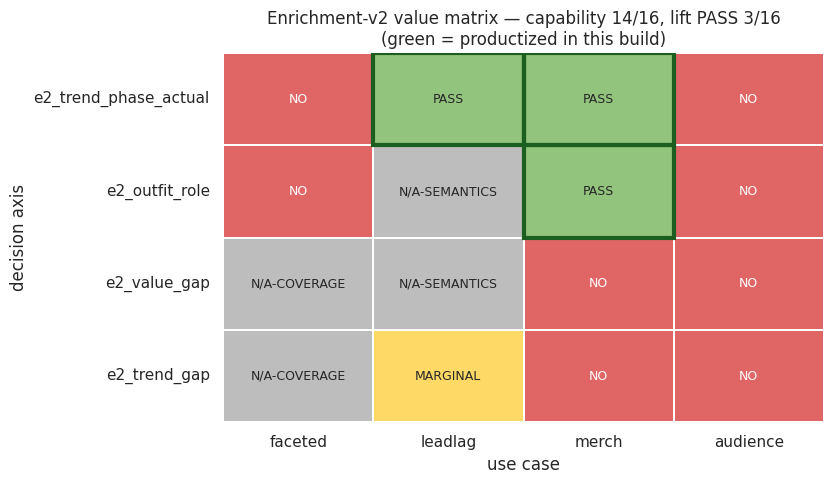

In [2]:
posture = value_matrix_posture(cfg)
print(f"capability {posture.attrs['capability_yes']}/{posture.attrs['n_cells']}  |  "
      f"behavior-validated lift PASS {posture.attrs['lift_pass']}/{posture.attrs['n_cells']}")
print('PRODUCTIZED:', posture.attrs['pass_cells'])
display(posture)

# --- value-matrix heatmap (verdict-colored, PASS highlighted) ---
USES = ['faceted', 'leadlag', 'merch', 'audience']
AXES = ['e2_trend_phase_actual', 'e2_outfit_role', 'e2_value_gap', 'e2_trend_gap']
VCODE = {'PASS': 3, 'MARGINAL': 2, 'NO': 1}
p = posture.copy()
p['axis_norm'] = p['axis'].str.replace('_sign', '', regex=False)
p['code'] = p['lift_verdict'].map(VCODE).fillna(0)  # N/A-* -> 0
grid = p.pivot_table(index='axis_norm', values='code', columns='use', aggfunc='first').reindex(index=AXES, columns=USES)
labels = p.pivot_table(index='axis_norm', values='lift_verdict', columns='use', aggfunc='first').reindex(index=AXES, columns=USES)
fig, ax = plt.subplots(figsize=(8.5, 5.0))
cmap = sns.color_palette(['#bdbdbd', '#e06666', '#ffd966', '#93c47d'])
sns.heatmap(grid, annot=labels.fillna('N/A').values, fmt='', cmap=cmap, vmin=0, vmax=3,
            cbar=False, linewidths=1.2, linecolor='white', ax=ax,
            annot_kws={'fontsize': 9})
# green border on the 3 productized PASS cells
for _, r in p[p['productized']].iterrows():
    yi, xi = AXES.index(r['axis_norm']), USES.index(r['use'])
    ax.add_patch(plt.Rectangle((xi, yi), 1, 1, fill=False, edgecolor='#1b5e20', lw=3))
ax.set_title('Enrichment-v2 value matrix — capability 14/16, lift PASS 3/16\n(green = productized in this build)')
ax.set_xlabel('use case'); ax.set_ylabel('decision axis')
plt.tight_layout(); plt.savefig(FIG_DIR / '06_value_matrix_posture.png', dpi=DPI, bbox_inches='tight')
plt.show()

## Part 1 — Scenario A · Trend lead-time (3-month 카테고리 수요 조기경보)

**페르소나: category buyer.** 한 카테고리의 *hot(Emerging+Rising) 아이템 share* 가 그 카테고리 매출을 ~3개월 **선행**한다(canonical r=0.472, permutation null 0.062, lag=3mo). 운영 brief는 현재 hot-share가 자기 이력 대비 얼마나 *상승*했는지(z-score)로 카테고리를 랭킹 → '3개월 뒤 수요 상승' 조기경보.

⚠️ *modest* 상관(22개월·10 카테고리, CI 넓음). 카테고리 수준 신호이지 per-item 예측이 아니다. lag-3가 lag-1/2/4보다 corr이 높다는 점이 '선행' 구조의 증거.

Trend lead-time — 3-month category demand early-warning
confidence: ConfidenceCard(cell='e2_trend_phase_actual→leadlag', metric='lead-lag r: hot-share(t) → category sales(t+best_lag)', value=0.4723, baseline=0.0616, ci_lo=0.1941, ci_hi=0.6395, verdict='PASS', source='probe_E2b_result.json', best_lag=3)
행동-파생 trend_phase 축(LLM 아님). 검증된 lead-lag r=0.4723 (permutation null 0.0616, lag=3mo, CI[0.1941,0.6395]) — 22개월·10 카테고리의 modest 상관(CI 넓음). 카테고리 수준 조기경보용이며 per-item 예측·추천 정확도(별도 negative)와는 다르다.


,category,latest_hot_share,hist_mean_share,share_zscore,share_trend_3mo,latest_month_sales,early_warning
0,Divided,0.8990,0.4321,2.028,0.2168,345212,high
1,Lingeries/Tights,0.9107,0.4601,2.022,0.1966,404460,high
2,Ladieswear,0.9128,0.4260,1.978,0.2042,736522,high
3,Sport,0.7791,0.3179,1.929,0.2239,55986,high
4,Menswear,0.8384,0.4373,1.911,0.2721,100933,high
5,Ladies Accessories,0.8181,0.4032,1.829,0.1811,97543,high
6,Children Sizes 134-170,0.7517,0.4960,1.044,0.1669,8422,high
7,Baby Sizes 50-98,0.7267,0.4912,0.932,0.1352,6681,elevated
8,"Children Accessories, Swimwear",0.7139,0.5070,0.819,0.1174,2562,elevated
9,Children Sizes 92-140,0.6974,0.5138,0.684,0.2340,6186,elevated


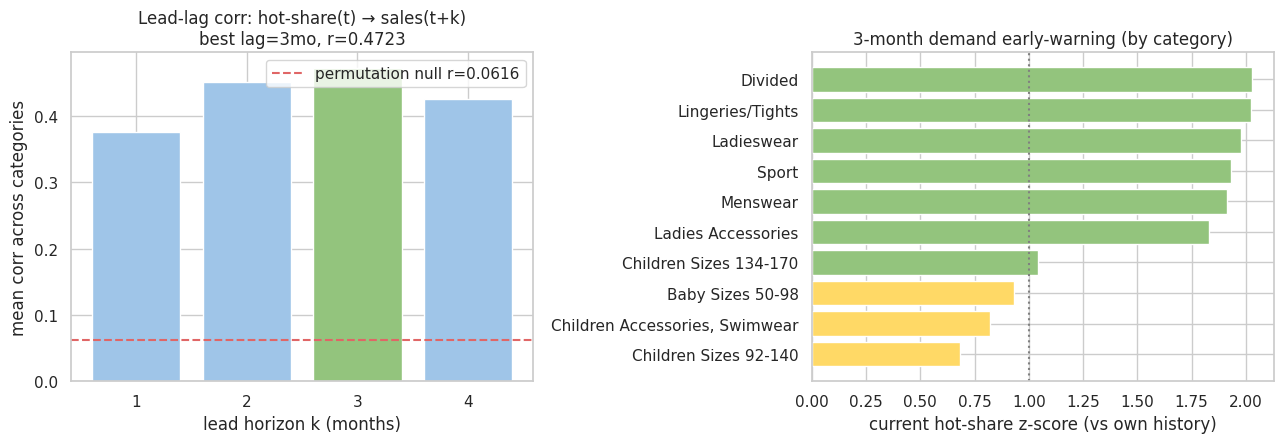

In [3]:
briefA = trend_leadtime_brief(cfg)
print(briefA.title); print('confidence:', briefA.confidence); print(briefA.caveat)
display(briefA.table)

by_lag = briefA.extra['lead_lag_by_lag']; best = briefA.extra['best_lag']
share = briefA.extra['share_timeseries']
null_r = briefA.confidence.baseline
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# (a) lead-lag corr by horizon vs permutation null
lags = sorted(by_lag); vals = [by_lag[k] for k in lags]
bars = axes[0].bar([str(k) for k in lags], vals, color=['#93c47d' if k==best else '#9fc5e8' for k in lags])
axes[0].axhline(null_r, ls='--', color='#e06666', label=f'permutation null r={null_r}')
axes[0].set_title(f'Lead-lag corr: hot-share(t) → sales(t+k)\nbest lag={best}mo, r={briefA.confidence.value}')
axes[0].set_xlabel('lead horizon k (months)'); axes[0].set_ylabel('mean corr across categories'); axes[0].legend()
# (b) early-warning ranking by current hot-share z-score
t = briefA.table.sort_values('share_zscore')
colors = {'high': '#93c47d', 'elevated': '#ffd966', 'watch': '#bdbdbd'}
axes[1].barh(t['category'], t['share_zscore'], color=[colors.get(w, '#bdbdbd') for w in t['early_warning']])
axes[1].axvline(1.0, ls=':', color='gray'); axes[1].set_xlabel('current hot-share z-score (vs own history)')
axes[1].set_title('3-month demand early-warning (by category)')
plt.tight_layout(); plt.savefig(FIG_DIR / '06_trend_leadtime.png', dpi=DPI, bbox_inches='tight'); plt.show()

## Part 2 — Scenario B · Launch first-week sell-through (트렌드-페이즈 런칭 신호)

**페르소나: launch planner.** trend_phase가 신규 아이템의 **first-week sell-through**를 설명한다(η=0.673, product_group residualize, metadata 0.223). E2-2의 velocity(=sales-rate, momentum과 tautology)를 first-week sell-through로 교체해 정당화된 셀. 운영 brief는 hot cohort(Emerging+Rising, 최소구매 floor)를 예상 sell-through 티어로 스코어링 → 재고배분·우선순위.

Launch signal — first-week sell-through by trend-phase
confidence: ConfidenceCard(cell='e2_trend_phase_actual→merch', metric='η(first_week_sell_through | resid product_group) vs metadata', value=0.6727, baseline=0.2228, ci_lo=0.4285, ci_hi=0.4581, verdict='PASS', source='probe_E2b_result.json', best_lag=None)
행동-파생 trend_phase 축(LLM 아님). η=0.6727 (resid product_group, metadata 0.2228, CI[0.4285,0.4581]). velocity 대신 first_week_sell_through 사용(momentum=sales-rate tautology 회피). 신규 런칭 재고배분·우선순위용이며 추천 정확도(별도 negative)와 무관.


,e2_trend_phase_actual,n_items,mean_first_week_sell_through,median_first_week_sell_through,sell_through_tier
0,Insufficient,19205,0.542569,0.500000,High
1,Emerging,11528,0.184351,0.090909,High
2,Rising,33960,0.116388,0.074074,Medium
3,Declining,26860,0.080384,0.045455,Medium
4,Mature,2150,0.063163,0.033172,Low
5,Peak,2206,0.057928,0.039216,Low


,article_id,e2_trend_phase_actual,e2_trend_momentum,first_week_sell_through,expected_sell_through_tier,total_purchases,n_buyers,velocity
0,0916881002,Emerging,2.995732,1.0,High,19.0,18.0,3.800000
1,0926668001,Emerging,2.708050,1.0,High,14.0,13.0,14.000000
2,0918591002,Emerging,2.564949,1.0,High,12.0,12.0,3.000000
3,0852374006,Emerging,5.087596,1.0,High,161.0,137.0,32.200000
4,0875469007,Emerging,5.877736,1.0,High,356.0,326.0,118.666667
5,0935356001,Emerging,3.871201,1.0,High,47.0,42.0,9.400000
6,0917624001,Emerging,2.772589,1.0,High,15.0,14.0,3.000000
7,0918597001,Emerging,2.639057,1.0,High,13.0,12.0,13.000000
8,0806241007,Emerging,4.189655,1.0,High,65.0,62.0,21.666667
9,0873001004,Emerging,3.218876,1.0,High,24.0,21.0,6.000000


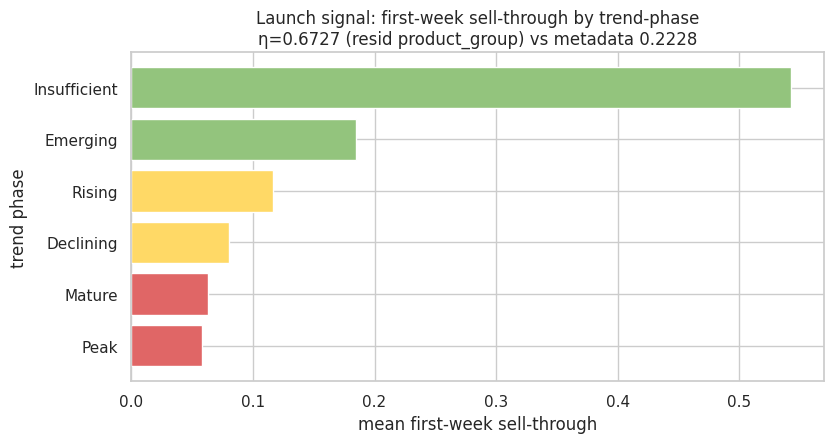

In [4]:
briefB = launch_signal_brief(cfg, top_k=25)
print(briefB.title); print('confidence:', briefB.confidence); print(briefB.caveat)
ps = briefB.extra['phase_sellthrough']
display(ps)
display(briefB.table.head(15))

c = briefB.confidence
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ps2 = ps.sort_values('mean_first_week_sell_through')
tier_color = {'High': '#93c47d', 'Medium': '#ffd966', 'Low': '#e06666'}
ax.barh(ps2['e2_trend_phase_actual'], ps2['mean_first_week_sell_through'],
        color=[tier_color.get(t, '#bdbdbd') for t in ps2['sell_through_tier']])
ax.set_xlabel('mean first-week sell-through'); ax.set_ylabel('trend phase')
ax.set_title(f'Launch signal: first-week sell-through by trend-phase\nη={c.value} (resid product_group) vs metadata {c.baseline}')
plt.tight_layout(); plt.savefig(FIG_DIR / '06_launch_signal.png', dpi=DPI, bbox_inches='tight'); plt.show()

## Part 3 — Scenario C · Co-purchase velocity / bundle-anchor (아웃핏-역할)

**페르소나: cross-sell / bundling merchandiser.** same-basket cross-group co-purchase로 도출한 **outfit_role**이 판매 velocity를 설명한다(η=0.631, product_group residualize, metadata 0.534). 역할별 velocity 티어 + 머천다이징 번들 라벨(Anchor-hub=cross-sell 앵커 등). 운영 brief는 anchor 역할(Anchor-hub·Versatile-connector) 아이템을 velocity로 랭킹 → 번들 앵커 재고 우선순위.

Co-purchase velocity — bundle-anchor prioritization by outfit-role
confidence: ConfidenceCard(cell='e2_outfit_role→merch', metric='η(velocity | resid product_group) vs metadata', value=0.631, baseline=0.5335, ci_lo=0.0851, ci_hi=0.1058, verdict='PASS', source='probe_E2b_result.json', best_lag=None)
행동-파생 outfit_role 축(LLM 아님). η=0.631 (resid product_group, metadata 0.5335, CI[0.0851,0.1058]). co-purchase 그래프 역할 → cross-sell 앵커·번들 우선순위용. 추천 정확도(별도 negative)와 무관.


,e2_outfit_role,n_items,mean_velocity,median_velocity,velocity_tier,bundle_role
0,Anchor-hub,34760,2.808359,1.504873,High,Cross-sell anchor — high co-purchase intensity...
1,Complement-addon,5113,1.247259,0.653422,High,Attach item — intense but narrow partners; bun...
2,Versatile-connector,5204,0.674364,0.317395,Medium,Category bridge — pairs across many groups; cr...
3,Standalone,16167,0.444848,0.137255,Low,No co-purchase signal — merchandise solo
4,Niche-pair,34665,0.387402,0.177778,Low,Narrow pairing — limited co-purchase; targeted...


,article_id,e2_outfit_role,bundle_role,velocity_tier,velocity,total_purchases,n_buyers
0,0875469007,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,118.666667,356.0,326.0
1,0866261001,Versatile-connector,Category bridge — pairs across many groups; cr...,Medium,102.200000,511.0,421.0
2,0599580055,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,92.279570,8582.0,6383.0
3,0913030001,Versatile-connector,Category bridge — pairs across many groups; cr...,Medium,82.166667,493.0,366.0
4,0866260001,Versatile-connector,Category bridge — pairs across many groups; cr...,Medium,79.800000,399.0,317.0
5,0817472005,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,77.896552,2259.0,1897.0
6,0817472002,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,77.619048,3260.0,2837.0
7,0706016001,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,77.041308,44761.0,29288.0
8,0906729001,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,76.000000,380.0,329.0
9,0863570001,Anchor-hub,Cross-sell anchor — high co-purchase intensity...,High,71.285714,499.0,438.0


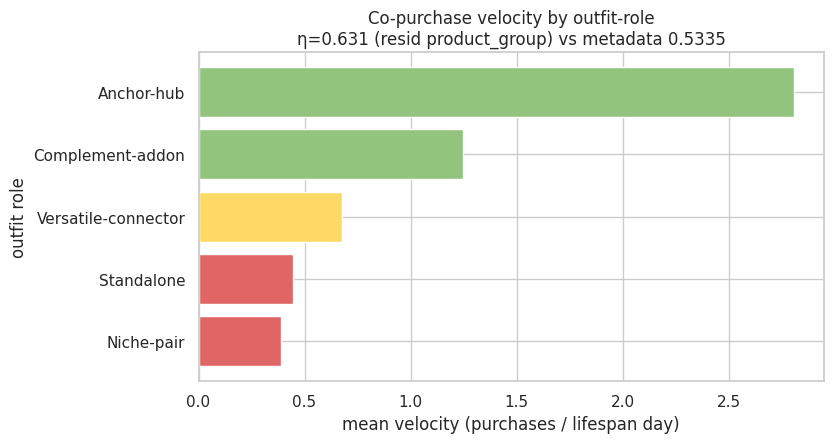

In [5]:
briefC = copurchase_velocity_brief(cfg, top_k=25)
print(briefC.title); print('confidence:', briefC.confidence); print(briefC.caveat)
rv = briefC.extra['role_velocity']
display(rv[['e2_outfit_role', 'n_items', 'mean_velocity', 'median_velocity', 'velocity_tier', 'bundle_role']])
display(briefC.table.head(15))

c = briefC.confidence
fig, ax = plt.subplots(figsize=(8.5, 4.6))
rv2 = rv.sort_values('mean_velocity')
tier_color = {'High': '#93c47d', 'Medium': '#ffd966', 'Low': '#e06666'}
ax.barh(rv2['e2_outfit_role'], rv2['mean_velocity'],
        color=[tier_color.get(t, '#bdbdbd') for t in rv2['velocity_tier']])
ax.set_xlabel('mean velocity (purchases / lifespan day)'); ax.set_ylabel('outfit role')
ax.set_title(f'Co-purchase velocity by outfit-role\nη={c.value} (resid product_group) vs metadata {c.baseline}')
plt.tight_layout(); plt.savefig(FIG_DIR / '06_copurchase_velocity.png', dpi=DPI, bbox_inches='tight'); plt.show()

## Part 4 — 정직한 경계: 제품화하지 *않는* 것

honesty-first posture의 핵심. 3 PASS만 제품화하고, 아래는 **의도적으로 제외**하되 맥락화한다:

- **① faceted-control (automatic lift) = NO**: D3에서 *oracle* steered precision 1.00 vs 0.14(capability YES)지만, *배포 가능한* history-predictor의 automatic gain은 0.0. → human-in-the-loop 필터 표면으로는 capability가 있으나 자동 개인화 lift는 없음. *제품화 X.*
- **④ audience = NO**: 축이 buyer-demographic divergence에서 metadata k-means를 못 넘음 (축은 category-직교). 마케팅 audience 세그먼터로 부적합.
- **gap축(`value_gap`·`trend_gap`) = NO**: capability는 비중복이나 행동적으로 inert (decision-lift 없음). 별도 research probe(백로그 b)로 hidden-value 해석 축 가치를 재검증 예정.
- **추천 정확도 = 별도 negative**: 이 매트릭스 밖. LLM L2/L3/외부지식이 L1 대비 정확도 개선 못함(full-scale −12%). 제품화 X.

**요약: capability vs lift는 다르다.** 제품화는 lift가 행동적으로 검증된 셀에만 한다.

In [6]:
not_prod = posture[~posture['productized']].copy()
not_prod['cell'] = not_prod['axis'] + '→' + not_prod['use']
display(not_prod[['cell', 'capability', 'lift_verdict', 'lift_value']]
        .sort_values('lift_verdict').reset_index(drop=True))
print('\n추천-정확도 negative (value matrix 밖, 제품화 X):')
print(posture.attrs['recsys_negative'])

# persist all three operational briefs for downstream use
OUT = PROJECT_ROOT / 'results' / 'tables' / 'merch_scenarios'
OUT.mkdir(parents=True, exist_ok=True)
for b in [briefA, briefB, briefC]:
    b.table.to_parquet(OUT / f'{b.name}.parquet', index=False)
    b.table.to_csv(OUT / f'{b.name}.csv', index=False)
print('briefs →', OUT)

,cell,capability,lift_verdict,lift_value
0,e2_trend_gap_sign→leadlag,YES,MARGINAL,0.0060
1,e2_value_gap→faceted,YES,N/A-COVERAGE,NaN
2,e2_trend_gap→faceted,YES,N/A-COVERAGE,NaN
3,e2_outfit_role→leadlag,PARTIAL,N/A-SEMANTICS,NaN
4,e2_value_gap→leadlag,PARTIAL,N/A-SEMANTICS,NaN
5,e2_trend_phase_actual→faceted,YES,NO,-0.1521
6,e2_trend_phase_actual→audience,YES,NO,-0.7716
7,e2_outfit_role→faceted,YES,NO,-0.1521
8,e2_outfit_role→audience,YES,NO,-0.6653
9,e2_value_gap→merch,YES,NO,-0.1424



추천-정확도 negative (value matrix 밖, 제품화 X):
추천 정확도(별도 probe): LLM L2/L3/외부지식은 L1 content 대비 H&M 추천 정확도를 개선하지 못함 — multiply-confirmed negative (full-scale −12%, probe_21/22). 이 value matrix 밖의 결과이며, 제품화하지 않고 맥락화만 한다.
briefs → /home/mail-agent/project/llm-factor-recsys-hnm/results/tables/merch_scenarios
